<a href="https://colab.research.google.com/github/suchkow/GitHub/blob/main/mcb_risks_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.DataFrame(pd.read_csv('Market Rates AFLT.csv', delimiter=',', skiprows=2))

In [ ]:
df.shape

(771, 22)

In [ ]:
df.tail(50)

,assetid1,isin,tradedate,range,range_start,range_end,discount_l,discount_h,rtl,price_rub,...,hpenrate,collateralpercent,collateral,fullcovered,fullcoveredlimit,updatetime,discount,rcl,rch,repodiscount
721,AFLT,RU0009062285,09.10.2024,2,2114147,10570735.0,56,56,23.368,53.108,...,NaN,100.0,0,0,0,08.10.2024 19:31:31,56,0.00,0.00,30
722,AFLT,RU0009062285,09.10.2024,3,10570735,NaN,63,63,19.650,53.108,...,NaN,100.0,0,0,0,08.10.2024 19:31:31,63,0.00,0.00,30
723,AFLT,RU0009062285,10.10.2024,1,0,2114147.0,50,50,26.778,53.556,...,NaN,100.0,0,0,0,09.10.2024 19:27:46,50,40.16,67.00,30
724,AFLT,RU0009062285,10.10.2024,2,2114147,10570735.0,56,56,23.565,53.556,...,NaN,100.0,0,0,0,09.10.2024 19:27:46,56,0.00,0.00,30
725,AFLT,RU0009062285,10.10.2024,3,10570735,NaN,63,63,19.816,53.556,...,NaN,100.0,0,0,0,09.10.2024 19:27:46,63,0.00,0.00,30
726,AFLT,RU0009062285,11.10.2024,1,0,2114147.0,50,50,26.956,53.912,...,NaN,100.0,0,0,0,10.10.2024 20:03:47,50,40.39,67.56,30
727,AFLT,RU0009062285,11.10.2024,2,2114147,10570735.0,56,56,23.721,53.912,...,NaN,100.0,0,0,0,10.10.2024 20:03:47,56,0.00,0.00,30
728,AFLT,RU0009062285,11.10.2024,3,10570735,NaN,63,63,19.947,53.912,...,NaN,100.0,0,0,0,10.10.2024 20:03:47,63,0.00,0.00,30
729,AFLT,RU0009062285,14.10.2024,1,0,2114147.0,50,50,27.410,54.819,...,NaN,100.0,0,0,0,11.10.2024 20:58:38,50,41.10,68.58,30
730,AFLT,RU0009062285,14.10.2024,2,2114147,10570735.0,56,56,24.120,54.819,...,NaN,100.0,0,0,0,11.10.2024 20:58:38,56,0.00,0.00,30


In [ ]:
print(df.columns)

Index(['assetid1', 'isin', 'tradedate', 'range', 'range_start', 'range_end',
       'discount_l', 'discount_h', 'rtl', 'price_rub', 'rth', 'lpenrate',
       'hpenrate', 'collateralpercent', 'collateral', 'fullcovered',
       'fullcoveredlimit', 'updatetime', 'discount', 'rcl', 'rch',
       'repodiscount'],
      dtype='object')


In [ ]:
df = df.drop(columns=['assetid1', 'isin', 'range', 'range_start', 'range_end',
       'discount_l', 'discount_h', 'rtl', 'rth', 'lpenrate',
       'hpenrate', 'updatetime', 'rcl', 'rch'])

In [ ]:
df['tradedate'] = pd.to_datetime(df['tradedate'], format='%d.%m.%Y')

In [ ]:
df.sort_values('tradedate')

,tradedate,price_rub,collateralpercent,collateral,fullcovered,fullcoveredlimit,discount,repodiscount
0,2023-10-31,39.851,100.0,0,0,0,50,30
1,2023-10-31,39.851,100.0,0,0,0,56,30
2,2023-10-31,39.851,100.0,0,0,0,63,30
3,2023-11-01,39.399,100.0,0,0,0,50,30
4,2023-11-01,39.399,100.0,0,0,0,56,30
...,...,...,...,...,...,...,...,...
765,2024-10-30,55.589,100.0,0,0,0,50,30
767,2024-10-30,55.589,100.0,0,0,0,63,30
769,2024-10-31,55.789,100.0,0,0,0,56,30
768,2024-10-31,55.789,100.0,0,0,0,50,30


In [ ]:
df = df.groupby('tradedate', as_index=False).mean()

In [ ]:
df['return'] = df['price_rub'].pct_change().fillna(0)
df = df.sort_values('return')

In [ ]:
df['bin'] = pd.cut(df['return'], 20)
df = df.drop(columns=['tradedate', 'collateralpercent', 'collateral', 'fullcovered', 'fullcoveredlimit', 'discount', 'repodiscount'])
df['price_rub_copy'] = df['price_rub']

In [ ]:
# df_bins = df.groupby('bin', as_index=False).mean()
df_bins = df.groupby('bin').agg(count=('price_rub_copy', 'count'), stock_return=('return', 'mean'), price_rub=('price_rub', 'mean')).reset_index().dropna()
df_bins = df_bins.sort_values('bin')
df_bins

<ipython-input-521-404d0d166f24>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_bins = df.groupby('bin').agg(count=('price_rub_copy', 'count'), stock_return=('return', 'mean'), price_rub=('price_rub', 'mean')).reset_index().dropna()


,bin,count,stock_return,price_rub
0,"(-0.0703, -0.0634]",1,-0.070141,52.087000
1,"(-0.0634, -0.0566]",1,-0.057384,53.665000
3,"(-0.0499, -0.0431]",1,-0.049340,45.125000
4,"(-0.0431, -0.0364]",3,-0.040822,55.013333
5,"(-0.0364, -0.0296]",4,-0.034182,49.352750
6,"(-0.0296, -0.0229]",14,-0.026042,46.633286
7,"(-0.0229, -0.0161]",17,-0.018114,50.240000
8,"(-0.0161, -0.00937]",24,-0.012291,46.943583
9,"(-0.00937, -0.00262]",53,-0.005979,45.944358
10,"(-0.00262, 0.00413]",44,0.000582,44.922659


<Axes: xlabel='stock_return'>

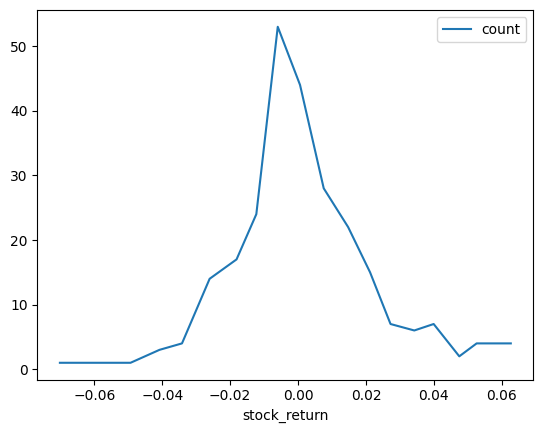

In [ ]:
from matplotlib import pyplot as plt
df_bins.plot(x='stock_return', y='count')

In [ ]:
mu = df_bins["stock_return"].mean()
sigma = df_bins["stock_return"].std()

print(f'mean: {mu}')
print(f'sd: {sigma}')

mean: -0.0003195837459992278
sd: 0.03933618724163138


In [ ]:
cl = 0.05

from scipy.stats import norm
var = abs(norm.ppf(cl, mu, sigma))

print(f'VaR at 95% for AFLT stock for 1 day horizon: {round(abs(var), 5)}')

VaR at 95% for AFLT stock for 1 day horizon: 0.06502


1 day: 6.5%
2 day: 9.2%
3 day: 11.26%
4 day: 13.0%
5 day: 14.54%
6 day: 15.93%
7 day: 17.2%
8 day: 18.39%
9 day: 19.51%
10 day: 20.56%


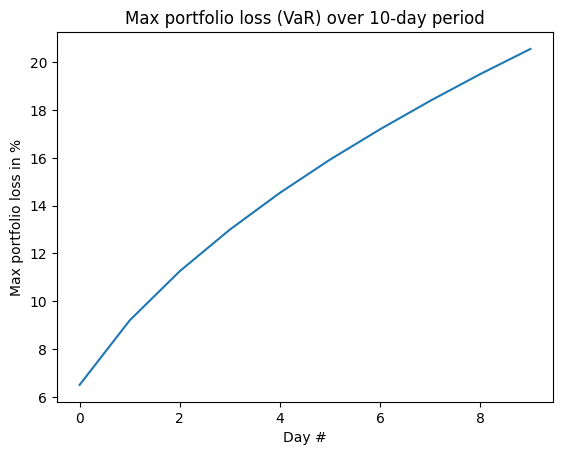

In [ ]:
var_array = []
num_days = int(10)

for x in range(1, num_days+1):
    var_array.append(np.round(var * np.sqrt(x) * 100,2))
    print(str(x) + f" day: " + str(np.round(var * np.sqrt(x) * 100,2)) + '%')

plt.xlabel("Day #")
plt.ylabel("Max portfolio loss in %")
plt.title(f"Max portfolio loss (VaR) over {num_days}-day period")
plt.plot(var_array)